# Pipeline de validacion de modelo elegido
Este notebook tiene el proceso de validación para el modelo de predicción de churn que se eligio en el propyecto principal, utilizando **PyCaret**. El objetivo es confirmar la robustez del modelo, optimizar el umbral de decisión y extraer insights de interpretabilidad en caso de se necesario

### PyCaret noes compatible con Python 3.12. Hay que usar si o s un runtime mas viejo, de 3.11 para abajo


In [13]:
#En caso de no tener instalado pycaret, descomentar la linea de abajo y ejecutar la celda
#!pip install "pycaret[full]"

In [8]:
import pandas as pd
from pycaret.classification import setup, compare_models, create_model, predict_model, pull, plot_model, compare_models, finalize_model
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

### 1. Selección y Comparativa de Modelos
En esta etapa, se probaron múltiples algoritmos para confirmar si la Regresión Logística sigue siendo la opción más sólida para este conjunto de datos.

In [3]:
# Loading data
df = pd.read_csv('churn_sintetico.csv')

# Direct setup and model comparison
s1 = setup(df, target='churn', session_id=123, verbose=False, html=False)
best_model = compare_models(n_select=3, verbose=False)

print('\nMejores Modelos:')
display(best_model)


Mejores Modelos:


[RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                 max_iter=None, positive=False, random_state=123, solver='auto',
                 tol=0.0001),
 LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                            priors=None, shrinkage=None, solver='svd',
                            store_covariance=False, tol=0.0001),
 LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                    intercept_scaling=1, l1_ratio=None, max_iter=1000,
                    multi_class='auto', n_jobs=None, penalty='l2',
                    random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                    warm_start=False)]

### 2. Calibracion del Umbral de Decisión
 Se preba usando el umbral de 0.441 usado enel proyecto para ver que metricas arroja

In [4]:
# creacion de modelo
lr = create_model('lr', verbose=False)

# predicciones
print('--- Metricas con el Threshold estandar (0.5) ---')
pred_default = predict_model(lr, verbose=False)
display(pull().iloc[0])

print('\n--- Metricas Threshold ajustado (0.441) ---')
pred_custom = predict_model(lr, probability_threshold=0.441, verbose=False)
display(pull().iloc[0])


print('\n Muestra de predicciones con el threshold de 0.441:')
display(pred_custom[['churn', 'prediction_label', 'prediction_score']].head())

--- Metricas con el Threshold estandar (0.5) ---


,0
Model,Logistic Regression
Accuracy,0.7407
AUC,0.7866
Recall,0.4892
Prec.,0.6614
F1,0.5624
Kappa,0.384
MCC,0.3928



--- Metricas Threshold ajustado (0.441) ---


,0
Model,Logistic Regression
Accuracy,0.7353
AUC,0.7866
Recall,0.589
Prec.,0.6168
F1,0.6026
Kappa,0.4044
MCC,0.4046



 Muestra de predicciones con el threshold de 0.441:


,churn,prediction_label,prediction_score
2512,0,0,0.9457
1323,0,0,0.8351
3171,1,1,0.6455
4544,0,0,0.7975
1181,0,0,0.9353


### 3. Diagnostico de Curvas y Error
se valida la precisión de las probabilidades con curvas de Calibración y Precision-Recall para asegurar que el modelo sea confiable en su nivel de riesgo.

In [5]:
import pandas as pd
from pycaret.classification import predict_model, pull

# Comparacion de valores segun el threshold

#threshold de 0.5
pred_default_df = predict_model(lr, verbose=False)
metrics_default = pull().iloc[0]

#threshold de 0.441
pred_custom_df = predict_model(lr, probability_threshold=0.441, verbose=False)
metrics_custom = pull().iloc[0]

data = {
    'Metrica': ['Accuracy', 'Recall (Sensitivity)', 'Precision', 'F1-Score'],
    'Default (0.5)': [
        metrics_default['Accuracy'],
        metrics_default['Recall'],
        metrics_default['Prec.'],
        metrics_default['F1']
    ],
    'Ajustado (0.441)': [
        metrics_custom['Accuracy'],
        metrics_custom['Recall'],
        metrics_custom['Prec.'],
        metrics_custom['F1']
    ]
}

threshold_comparison = pd.DataFrame(data)

# Aca se calcula el porcentaje de diferencia
threshold_comparison['% de cambio'] = ((threshold_comparison['Ajustado (0.441)'] - threshold_comparison['Default (0.5)']) / threshold_comparison['Default (0.5)'] * 100).round(2)

#display(threshold_comparison)

display(threshold_comparison.style.set_caption("impacto del ajuste del threshold").background_gradient(subset=['% de cambio'], cmap='RdYlGn'))


print(f"\nModelo: regresion logistica")
print(f"Threshold: 0.441")
print(f"Mejora del Recall: {threshold_comparison.loc[1, '% de cambio']}% ")
print(f"Mejroa del F1-Score: {threshold_comparison.loc[3, '% de cambio']}% ")

,Metrica,Default (0.5),Ajustado (0.441),% de cambio
0,Accuracy,0.740700,0.735300,-0.730000
1,Recall (Sensitivity),0.489200,0.589000,20.400000
2,Precision,0.661400,0.616800,-6.740000
3,F1-Score,0.562400,0.602600,7.150000



Modelo: regresion logistica
Threshold: 0.441
Mejora del Recall: 20.4% 
Mejroa del F1-Score: 7.15% 


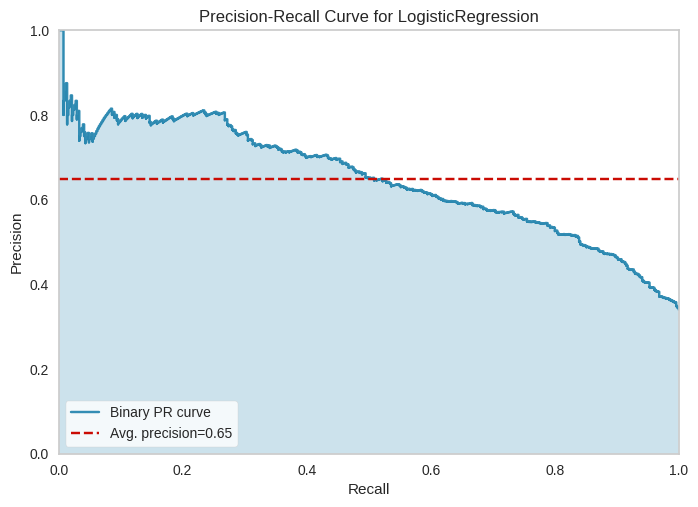

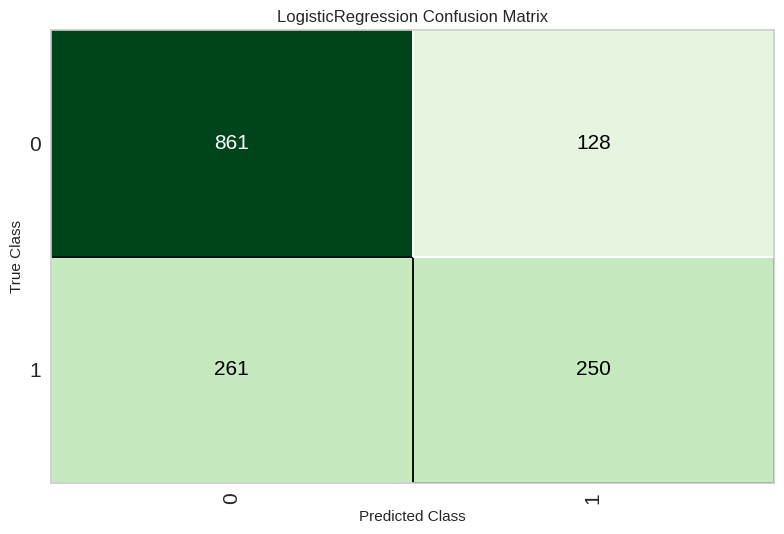

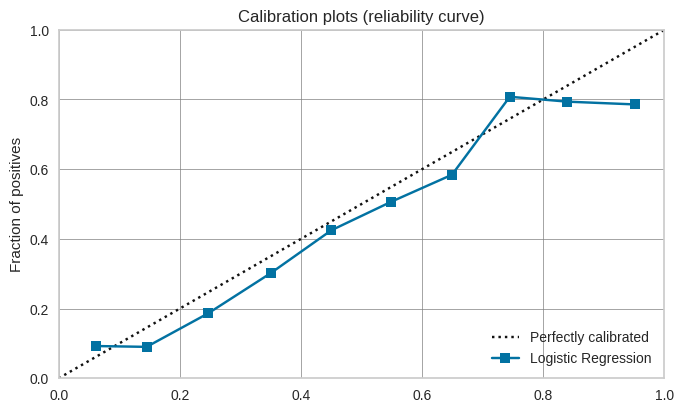

In [6]:
# Curva de precision
plot_model(lr, plot='pr')
#MAtriz de confusion
plot_model(lr, plot='confusion_matrix')
# Curva de Calibración
plot_model(lr, plot='calibration')

### 4. Finalizacion del modelo

In [10]:
final_lr = finalize_model(lr)

predictions = predict_model(final_lr, data=df, probability_threshold=0.441, verbose=False)

print('Modelop finaliozado con 0.441 de threshold.')
display(predictions[['churn', 'prediction_label', 'prediction_score']].head())


Modelop finaliozado con 0.441 de threshold.


,churn,prediction_label,prediction_score
0,1,1,0.6867
1,0,0,0.9137
2,1,0,0.6593
3,1,0,0.8196
4,0,0,0.7723


### 5. Comparacion del top 3 con el threshold ajustado de 0.441

In [11]:
results = []
print(f'comparacion de los tres mejores modelos con Threshold: 0.441\n')

for model in best_model:
    model_name = str(model).split('(')[0]


    predict_model(model, probability_threshold=0.441, verbose=False)
    metrics = pull().iloc[0]
    metrics['Model Name'] = model_name
    results.append(metrics)


comparison_df = pd.DataFrame(results)

cols = ['Model Name'] + [c for c in comparison_df.columns if c != 'Model Name']
print(comparison_df[cols].to_string(index=False))


comparacion de los tres mejores modelos con Threshold: 0.441

                Model Name                        Model  Accuracy    AUC  Recall  Prec.     F1  Kappa    MCC
           RidgeClassifier             Ridge Classifier    0.7433 0.6786  0.4755 0.6750 0.5580 0.3847 0.3964
LinearDiscriminantAnalysis Linear Discriminant Analysis    0.7320 0.7884  0.5851 0.6115 0.5980 0.3971 0.3974
        LogisticRegression          Logistic Regression    0.7353 0.7866  0.5890 0.6168 0.6026 0.4044 0.4046


### Analisis de features

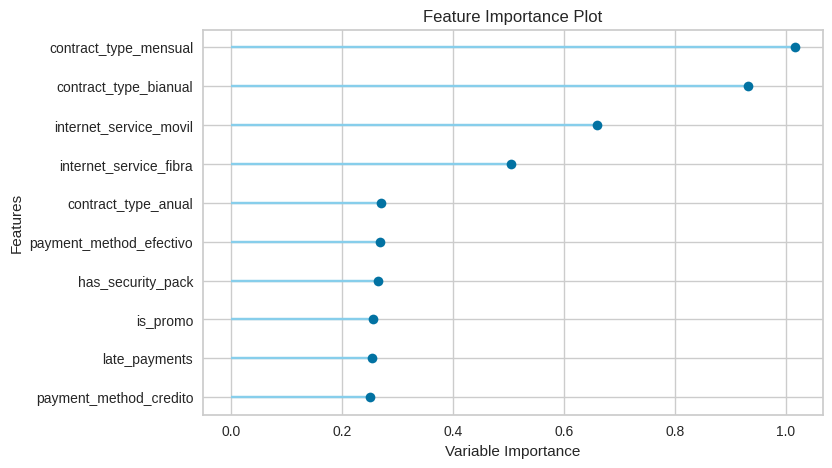


Top Features por Coeficiente:
                Feature  Coeficiente
  contract_type_mensual     1.015886
  contract_type_bianual    -0.932354
 internet_service_movil     0.659159
 internet_service_fibra    -0.505288
    contract_type_anual    -0.270421
payment_method_efectivo     0.268684
      has_security_pack    -0.263938
               is_promo     0.256347
          late_payments     0.253939
 payment_method_credito    -0.250525


In [12]:
# Importancia de los features
plot_model(lr, plot='feature')

coefs = lr.coef_[0]
feature_names = s1.train_transformed.columns.drop('churn')
importance_df = pd.DataFrame({'Feature': feature_names, 'Coeficiente': coefs})
importance_df['Abs_Coefficient'] = importance_df['Coeficiente'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

print('\nTop Features por Coeficiente:')
print(importance_df[['Feature', 'Coeficiente']].head(10).to_string(index=False))

# Conclusiones

Este trabajo de validación fue realizado sobre el modelo de **Regresión Logística** utilizando la librería PyCaret en un entorno controlado de Python 3.11.

## 1. Resumen
El modelo original fue validado y optimizado mediante la calibración del umbral de decisión. Se confirmó que la Regresión Logística es el modelo más robusto para este conjunto de datos, superando a alternativas como Random Forest en términos de AUC y consistencia.

## 2. Comparativa de Métricas (Calibración)
Se ajustó el umbral de probabilidad de **0.5** a **0.441** para priorizar la detección de bajas (Recall).

| Métrica | Base (0.5) | Calibrado (0.441) | Cambio % |
| :--- | :--- | :--- | :--- |
| **Accuracy** | 0.7407 | 0.7353 | -0.73% |
| **Recall** | 0.4892 | 0.5890 | **+20.40%** |
| **Precisión** | 0.6614 | 0.6168 | -6.74% |
| **F1-Score** | 0.5624 | 0.6026 | **+7.15%** |

## 3. Factores Clave de Abandono (Interpretabilidad)
Utilizando los coeficientes del modelo, se identificaron los siguientes impulsores principales:

*   **Riesgo Alto (Churn):** Contratos mensuales (`contract_type_mensual`), servicio de internet móvil y pagos atrasados.
*   **Retención (Lealtad):** Contratos a dos años (`contract_type_bianual`), servicio de fibra óptica y métodos de pago por crédito.

## 4. Conclusiones
La validación confirma que el modelo está listo para producción. El uso del umbral **0.441** permite capturar un **20% más de casos de churn**, lo cual es crítico para las campañas preventivas del negocio, manteniendo un equilibrio saludable con la precisión global.